### 01 - Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)

RESULTS_DIR = "../results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

BASE_ACC     = 69.25
TUNING_A_ACC = 71.46
TUNING_B_ACC = 88.71

print("✓ Imports ready")

✓ Imports ready


### 02 - Load predictions

In [2]:
df_A = pd.read_csv(f"{RESULTS_DIR}/qwen2vl_2b_tuningA.csv")
df_B = pd.read_csv(f"{RESULTS_DIR}/qwen2vl_2b_tuningB.csv")

# Map predictions and ground truth to indices 0-3
letter_to_idx = {"A": 0, "B": 1, "C": 2, "D": 3}

for df in [df_A, df_B]:
    df["pred_idx"] = df["prediction"].map(letter_to_idx)
    df["gt_idx"]   = df["ground_truth"].map(letter_to_idx)
    df["invalid"]  = df["prediction"] == "?"

print(f"Tuning A: {len(df_A)} predictions")
print(f"Tuning B: {len(df_B)} predictions")
print(f"\nInvalid predictions:")
print(f"  Tuning A: {df_A['invalid'].sum()} ({df_A['invalid'].mean()*100:.2f}%)")
print(f"  Tuning B: {df_B['invalid'].sum()} ({df_B['invalid'].mean()*100:.2f}%)")

Tuning A: 2330 predictions
Tuning B: 2330 predictions

Invalid predictions:
  Tuning A: 0 (0.00%)
  Tuning B: 0 (0.00%)


### 03 - Overall accuracy + F1

In [3]:
# Drop invalid predictions for metric computation
df_A_valid = df_A.dropna(subset=["pred_idx", "gt_idx"])
df_B_valid = df_B.dropna(subset=["pred_idx", "gt_idx"])

# F1 scores
f1_A = f1_score(df_A_valid["gt_idx"], df_A_valid["pred_idx"], average="macro")
f1_B = f1_score(df_B_valid["gt_idx"], df_B_valid["pred_idx"], average="macro")

# Cohen's Kappa
kappa_A = cohen_kappa_score(df_A_valid["gt_idx"], df_A_valid["pred_idx"])
kappa_B = cohen_kappa_score(df_B_valid["gt_idx"], df_B_valid["pred_idx"])

print("="*55)
print("OVERALL METRICS SUMMARY")
print("="*55)
print(f"{'Metric':<25} {'Tuning A':>12} {'Tuning B':>12}")
print("-"*55)
print(f"{'Accuracy (%)':<25} {TUNING_A_ACC:>12.2f} {TUNING_B_ACC:>12.2f}")
print(f"{'Macro F1':<25} {f1_A:>12.4f} {f1_B:>12.4f}")
print(f"{'Cohen Kappa':<25} {kappa_A:>12.4f} {kappa_B:>12.4f}")
print(f"{'Invalid Preds (%)':<25} {df_A['invalid'].mean()*100:>12.2f} {df_B['invalid'].mean()*100:>12.2f}")
print("="*55)

OVERALL METRICS SUMMARY
Metric                        Tuning A     Tuning B
-------------------------------------------------------
Accuracy (%)                     71.46        88.71
Macro F1                        0.7140       0.8867
Cohen Kappa                     0.6187       0.8493
Invalid Preds (%)                 0.00         0.00


### 04 - Classification report

In [4]:
labels      = [0, 1, 2, 3]
label_names = ["A", "B", "C", "D"]

print("=== Tuning A ===")
print(classification_report(
    df_A_valid["gt_idx"], df_A_valid["pred_idx"],
    labels=labels, target_names=label_names
))

print("=== Tuning B ===")
print(classification_report(
    df_B_valid["gt_idx"], df_B_valid["pred_idx"],
    labels=labels, target_names=label_names
))

=== Tuning A ===
              precision    recall  f1-score   support

           A       0.70      0.73      0.71       616
           B       0.70      0.71      0.70       583
           C       0.77      0.71      0.74       627
           D       0.70      0.70      0.70       504

    accuracy                           0.71      2330
   macro avg       0.71      0.71      0.71      2330
weighted avg       0.72      0.71      0.71      2330

=== Tuning B ===
              precision    recall  f1-score   support

           A       0.92      0.86      0.89       616
           B       0.90      0.89      0.89       583
           C       0.88      0.90      0.89       627
           D       0.84      0.91      0.87       504

    accuracy                           0.89      2330
   macro avg       0.89      0.89      0.89      2330
weighted avg       0.89      0.89      0.89      2330



### 05 - Confusion matrices

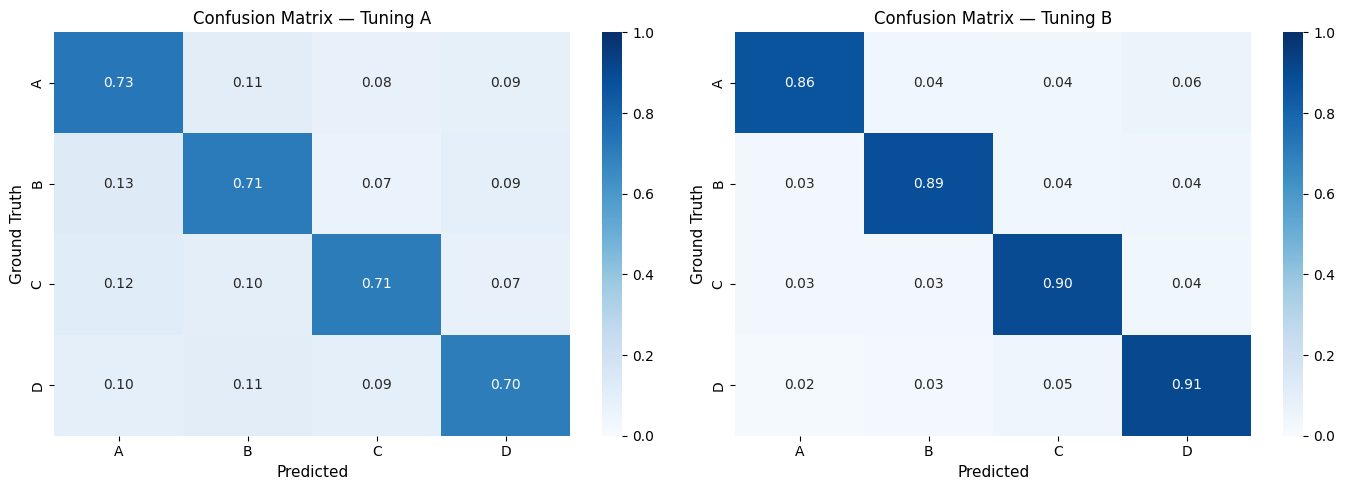

✓ Saved


In [5]:
cm_A = confusion_matrix(df_A_valid["gt_idx"], df_A_valid["pred_idx"], labels=labels)
cm_B = confusion_matrix(df_B_valid["gt_idx"], df_B_valid["pred_idx"], labels=labels)

# Normalize
cm_A_norm = cm_A.astype("float") / cm_A.sum(axis=1)[:, np.newaxis]
cm_B_norm = cm_B.astype("float") / cm_B.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(axes, [cm_A_norm, cm_B_norm], ["Tuning A", "Tuning B"]):
    sns.heatmap(
        cm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names,
        ax=ax, vmin=0, vmax=1
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Ground Truth", fontsize=11)
    ax.set_title(f"Confusion Matrix — {title}", fontsize=12)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_confusion_matrices.png", dpi=150)
plt.show()
print("✓ Saved")

### 06 - Answer distribution bias

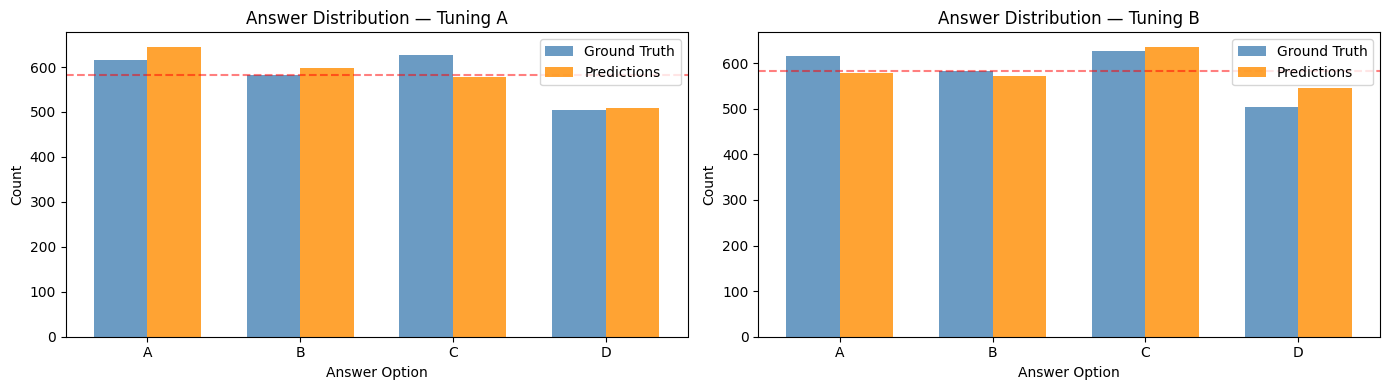

✓ Saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title in zip(axes, [df_A, df_B], ["Tuning A", "Tuning B"]):
    # Ground truth distribution
    gt_dist   = df["ground_truth"].value_counts().sort_index()
    pred_dist = df["prediction"].value_counts().sort_index()

    x     = np.arange(4)
    width = 0.35

    ax.bar(x - width/2, gt_dist.reindex(["A","B","C","D"], fill_value=0),
           width, label="Ground Truth", color="steelblue", alpha=0.8)
    ax.bar(x + width/2, pred_dist.reindex(["A","B","C","D"], fill_value=0),
           width, label="Predictions",  color="darkorange", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(["A","B","C","D"])
    ax.set_xlabel("Answer Option")
    ax.set_ylabel("Count")
    ax.set_title(f"Answer Distribution — {title}")
    ax.legend()
    ax.axhline(y=len(df)/4, color="red", linestyle="--",
               alpha=0.5, label="Expected uniform")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_answer_distribution.png", dpi=150)
plt.show()
print("✓ Saved")

### 07 -  abcLabel per category breakdown

In [7]:
# For each category, compute abcLabel vs descriptive accuracy for A and B
results = []
for cat in df_B["category"].unique():
    for abc in [True, False]:
        sub_A = df_A[(df_A["category"] == cat) & (df_A["abc_label"] == abc)]
        sub_B = df_B[(df_B["category"] == cat) & (df_B["abc_label"] == abc)]

        if len(sub_A) == 0 and len(sub_B) == 0:
            continue

        results.append({
            "category":   cat,
            "abc_label":  "abcLabel" if abc else "Descriptive",
            "tuningA_acc": sub_A["correct"].mean() * 100 if len(sub_A) > 0 else None,
            "tuningB_acc": sub_B["correct"].mean() * 100 if len(sub_B) > 0 else None,
            "n_A": len(sub_A),
            "n_B": len(sub_B),
        })

df_cat_abc = pd.DataFrame(results)
df_cat_abc["delta"] = df_cat_abc["tuningB_acc"] - df_cat_abc["tuningA_acc"]

print("abcLabel questions — per category improvement (Tuning B - Tuning A):")
abc_only = df_cat_abc[df_cat_abc["abc_label"] == "abcLabel"].sort_values("delta", ascending=False)
print(abc_only[["category","tuningA_acc","tuningB_acc","delta","n_B"]].to_string(index=False))

print("\nDescriptive questions — per category improvement:")
desc_only = df_cat_abc[df_cat_abc["abc_label"] == "Descriptive"].sort_values("delta", ascending=False)
print(desc_only[["category","tuningA_acc","tuningB_acc","delta","n_B"]].to_string(index=False))

abcLabel questions — per category improvement (Tuning B - Tuning A):
                 category  tuningA_acc  tuningB_acc     delta  n_B
                rockCycle    29.545455   100.000000 70.454545   44
               rockStrata    15.384615    84.615385 69.230769   13
            waterCNPCycle    35.000000   100.000000 65.000000   20
         moonPhaseEquinox    38.068182    94.318182 56.250000  176
                  volcano    22.222222    77.777778 55.555556    9
               lifeCycles    41.346154    94.711538 53.365385  208
        faultsEarthquakes    44.444444    94.444444 50.000000   18
photosynthesisRespiration    44.444444    91.666667 47.222222   36
                  typesOf    47.651007    93.959732 46.308725  149
                 partsOfA    46.242775    91.329480 45.086705  173
            atomStructure    66.666667   100.000000 33.333333    3
          partsOfTheEarth    52.631579    84.210526 31.578947   19
              solarSystem    80.000000   100.000000 20.00000

### 08 - McNemar's test (statistical significance)

In [9]:
from statsmodels.stats.contingency_tables import mcnemar

# Build contingency table
# a = both correct, b = A correct B wrong, c = A wrong B correct, d = both wrong
both_correct  = ((df_A["correct"] == True)  & (df_B["correct"] == True)).sum()
A_only        = ((df_A["correct"] == True)  & (df_B["correct"] == False)).sum()
B_only        = ((df_A["correct"] == False) & (df_B["correct"] == True)).sum()
both_wrong    = ((df_A["correct"] == False) & (df_B["correct"] == False)).sum()

table = np.array([[both_correct, A_only],
                  [B_only,       both_wrong]])

result = mcnemar(table, exact=False, correction=True)

print("="*50)
print("McNEMAR'S TEST — Tuning A vs Tuning B")
print("="*50)
print(f"Contingency table:")
print(f"  Both correct:       {both_correct}")
print(f"  Only A correct:     {A_only}")
print(f"  Only B correct:     {B_only}")
print(f"  Both wrong:         {both_wrong}")
print(f"\nStatistic: {result.statistic:.4f}")
print(f"p-value:   {result.pvalue:.6f}")
if result.pvalue < 0.05:
    print("→ SIGNIFICANT difference (p < 0.05)")
    print("→ Tuning B is statistically better than Tuning A")
else:
    print("→ No significant difference (p >= 0.05)")
print("="*50)

McNEMAR'S TEST — Tuning A vs Tuning B
Contingency table:
  Both correct:       1540
  Only A correct:     125
  Only B correct:     527
  Both wrong:         138

Statistic: 246.6273
p-value:   0.000000
→ SIGNIFICANT difference (p < 0.05)
→ Tuning B is statistically better than Tuning A


### 09 - Question length vs accuracy

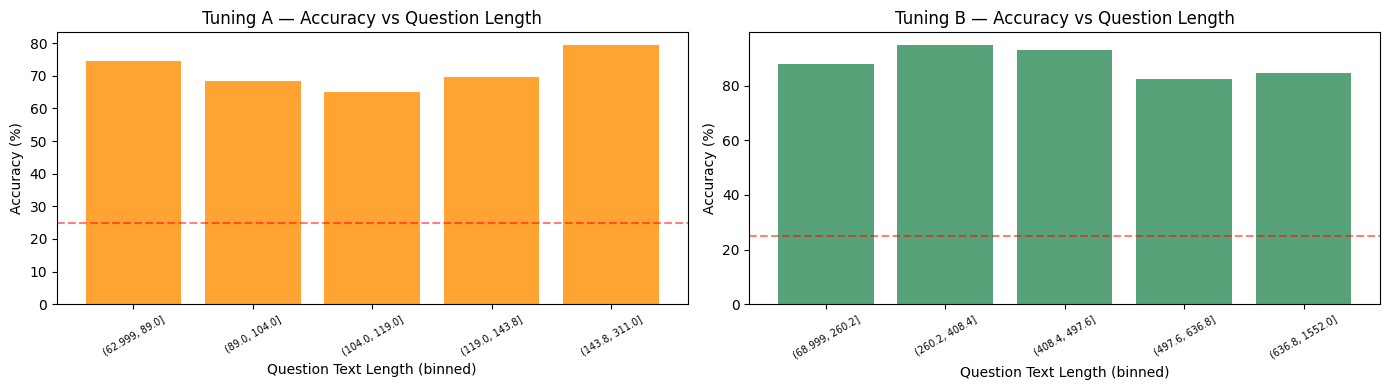

✓ Saved


In [10]:
for df, title, color in [
    (df_A, "Tuning A", "darkorange"),
    (df_B, "Tuning B", "seagreen")
]:
    df["q_length"] = df["question_id"].map(
        lambda qid: len(str(qid))
    )

# Use user_text length as proxy for question length
# Reload from test data to get question text lengths
with open("../processed_data/splits/test_vA.json") as f:
    test_A = json.load(f)
with open("../processed_data/splits/test_vB.json") as f:
    test_B = json.load(f)

len_map_A = {s["question_id"]: len(s["user_text"]) for s in test_A}
len_map_B = {s["question_id"]: len(s["user_text"]) for s in test_B}

df_A["text_length"] = df_A["question_id"].map(len_map_A)
df_B["text_length"] = df_B["question_id"].map(len_map_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title, color in [
    (axes[0], df_A, "Tuning A", "darkorange"),
    (axes[1], df_B, "Tuning B", "seagreen"),
]:
    # Bin by text length
    df["length_bin"] = pd.qcut(df["text_length"], q=5, duplicates="drop")
    bin_acc = df.groupby("length_bin")["correct"].mean() * 100

    ax.bar(range(len(bin_acc)), bin_acc.values, color=color, alpha=0.8)
    ax.set_xticks(range(len(bin_acc)))
    ax.set_xticklabels([str(b) for b in bin_acc.index], rotation=30, fontsize=7)
    ax.set_xlabel("Question Text Length (binned)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"{title} — Accuracy vs Question Length")
    ax.axhline(y=25, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_question_length_accuracy.png", dpi=150)
plt.show()
print("✓ Saved")

### 10 - Final summary save

In [11]:
summary = pd.DataFrame([
    {
        "Condition":         "Base (zero-shot)",
        "Accuracy (%)":      BASE_ACC,
        "Macro F1":          "—",
        "Cohen Kappa":       "—",
        "abcLabel Acc (%)":  "~69",
        "Descriptive Acc (%)": "~69",
        "Invalid Preds (%)": "—",
    },
    {
        "Condition":         "Tuning A (image+Q)",
        "Accuracy (%)":      TUNING_A_ACC,
        "Macro F1":          round(f1_A, 4),
        "Cohen Kappa":       round(kappa_A, 4),
        "abcLabel Acc (%)":  round(df_A[df_A["abc_label"]==True]["correct"].mean()*100, 2),
        "Descriptive Acc (%)": round(df_A[df_A["abc_label"]==False]["correct"].mean()*100, 2),
        "Invalid Preds (%)": round(df_A["invalid"].mean()*100, 2),
    },
    {
        "Condition":         "Tuning B (image+Q+annotation)",
        "Accuracy (%)":      TUNING_B_ACC,
        "Macro F1":          round(f1_B, 4),
        "Cohen Kappa":       round(kappa_B, 4),
        "abcLabel Acc (%)":  round(df_B[df_B["abc_label"]==True]["correct"].mean()*100, 2),
        "Descriptive Acc (%)": round(df_B[df_B["abc_label"]==False]["correct"].mean()*100, 2),
        "Invalid Preds (%)": round(df_B["invalid"].mean()*100, 2),
    },
])

print("="*80)
print("FINAL METRICS SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

summary.to_csv(f"{RESULTS_DIR}/final_metrics_summary.csv", index=False)
print("✓ Saved")

FINAL METRICS SUMMARY
                    Condition  Accuracy (%) Macro F1 Cohen Kappa abcLabel Acc (%) Descriptive Acc (%) Invalid Preds (%)
             Base (zero-shot)         69.25        —           —              ~69                 ~69                 —
           Tuning A (image+Q)         71.46    0.714      0.6187            42.62               89.42               0.0
Tuning B (image+Q+annotation)         88.71   0.8867      0.8493            93.29               85.86               0.0
✓ Saved
